# Previsão de Risco de Crédito com XGBoost

Notebook baseado em **Gao, Sun & Sui (2021)** — *"Research on Default Prediction for Credit Card Users Based on XGBoost-LSTM Model"*.

Objetivo: prever inadimplência de clientes de cartão de crédito usando o dataset **UCI Credit Card Default** (30.000 clientes, Taiwan).

Pipeline: EDA → Feature Engineering (Seção 4.2 do artigo) → Modelos baseline (LR, DT, RF) → XGBoost → SHAP → Análise incremental do FE.

## Seção 1 — Instalação e Importações

Instalar pacotes e importar todas as bibliotecas necessárias. O dataset será baixado via `ucimlrepo` que conecta direto ao repositório UCI.

In [ ]:
# Descomentar se necessário em ambiente novo
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap xlrd

In [ ]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, classification_report
)

from xgboost import XGBClassifier
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports OK')

Imports OK


## Seção 2 — Carregamento dos Dados

Carregar `dataset.xls` (UCI Default of Credit Card Clients, baixado localmente). Arquivo tem cabeçalho em duas linhas — primeira linha é `X1..X23, Y`, segunda linha são os nomes reais. Usar `header=1` para pular a primeira. Renomear target `default payment next month` → `default` e remover coluna `ID`.

*Obs:* `.xls` antigo requer `xlrd`; rodar `!pip install xlrd` se necessário.

In [ ]:
df = pd.read_excel('dataset.xls', header=1)

df = df.rename(columns={'default payment next month': 'default'})

# PAY_1 vem como PAY_0 em algumas versões — normalizar
if 'PAY_1' in df.columns and 'PAY_0' not in df.columns:
    df = df.rename(columns={'PAY_1': 'PAY_0'})

print('Shape:', df.shape)
df.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


**Interpretação:** Dataset com 30.000 linhas e 25 colunas. Variáveis numéricas (limite, faturas, pagamentos) em NT\$, e categóricas codificadas como inteiros. Sem nulos aparentes pelo `.info()`.

## Seção 3 — Análise Exploratória dos Dados (EDA)

Explorar distribuições do target, das variáveis demográficas e do comportamento de pagamento ao longo dos 6 meses.

### 3.1 Distribuição do target

Verificar desbalanceamento — esperado ~22% inadimplentes segundo o artigo.

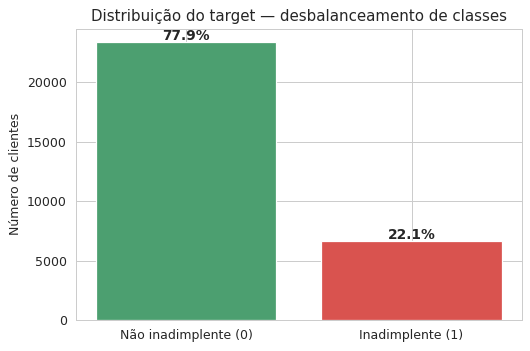

default
0    23364
1     6636
Name: count, dtype: int64


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['default'].value_counts().sort_index()
pct = counts / counts.sum() * 100
bars = ax.bar(['Não inadimplente (0)', 'Inadimplente (1)'], counts.values,
              color=['#4C9F70', '#D9534F'])
for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{p:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribuição do target — desbalanceamento de classes')
ax.set_ylabel('Número de clientes')
plt.tight_layout()
plt.show()
print(counts)

### 3.2 Variáveis categóricas vs. target

`SEX`, `EDUCATION`, `MARRIAGE` — comparar inadimplência por grupo.

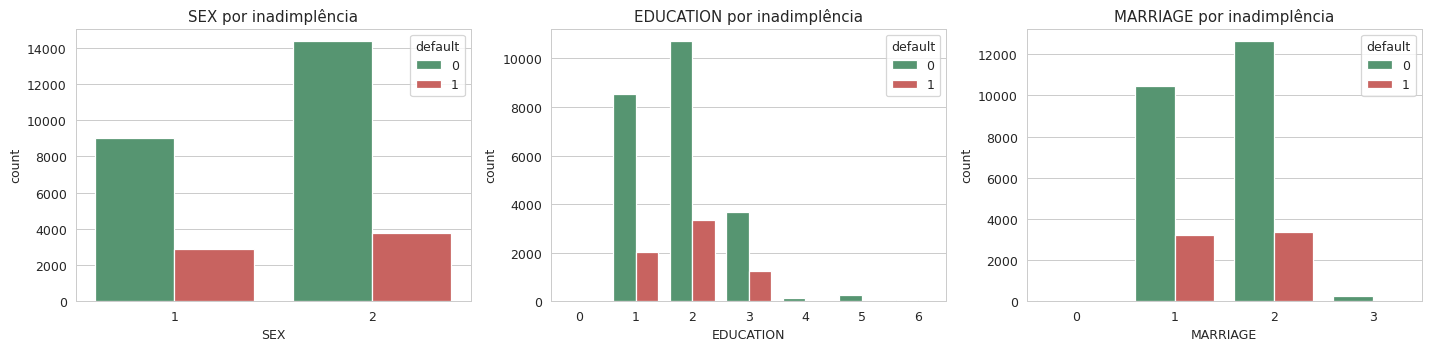

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['SEX', 'EDUCATION', 'MARRIAGE']):
    sns.countplot(data=df, x=col, hue='default', ax=ax,
                  palette=['#4C9F70', '#D9534F'])
    ax.set_title(f'{col} por inadimplência')
plt.tight_layout()
plt.show()

### 3.3 Idade e limite de crédito

Histogramas com KDE separados por target.

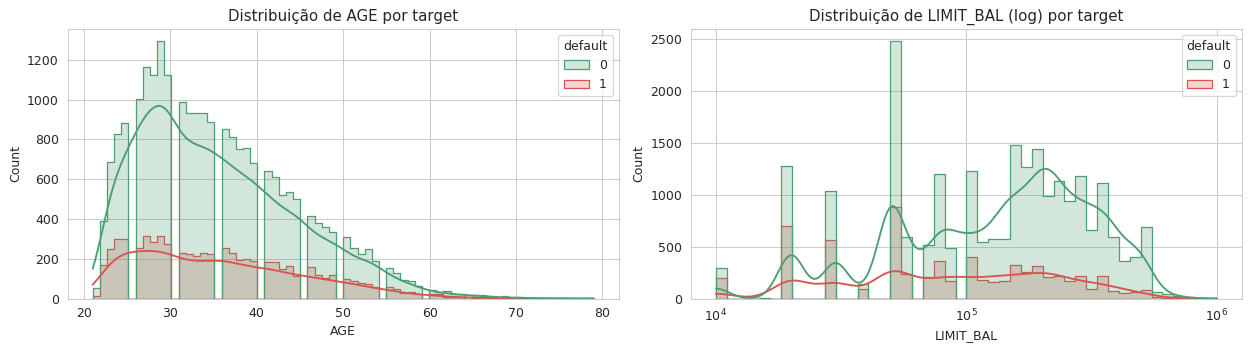

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x='AGE', hue='default', kde=True, ax=axes[0],
             palette=['#4C9F70', '#D9534F'], element='step')
axes[0].set_title('Distribuição de AGE por target')

sns.histplot(data=df, x='LIMIT_BAL', hue='default', kde=True, ax=axes[1],
             palette=['#4C9F70', '#D9534F'], element='step', log_scale=(True, False))
axes[1].set_title('Distribuição de LIMIT_BAL (log) por target')
plt.tight_layout()
plt.show()

### 3.4 Status de pagamento ao longo do tempo

Heatmap da média de `PAY_0..PAY_6` por grupo. Inadimplentes acumulam atrasos progressivos.

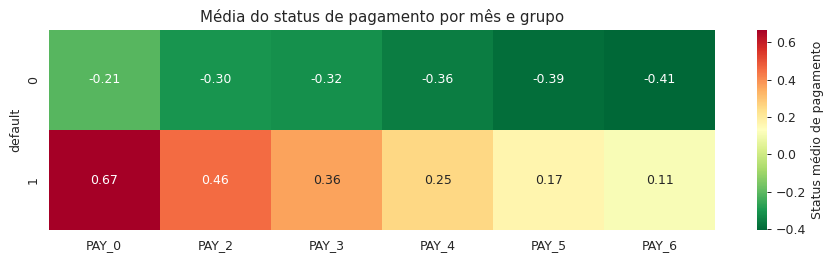

In [ ]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
pay_by_default = df.groupby('default')[pay_cols].mean()

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(pay_by_default, annot=True, fmt='.2f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Status médio de pagamento'}, ax=ax)
ax.set_title('Média do status de pagamento por mês e grupo')
ax.set_ylabel('default')
plt.tight_layout()
plt.show()

### 3.5 Evolução do saldo da fatura

Linha plot comparando média de `BILL_AMT1..BILL_AMT6` entre grupos.

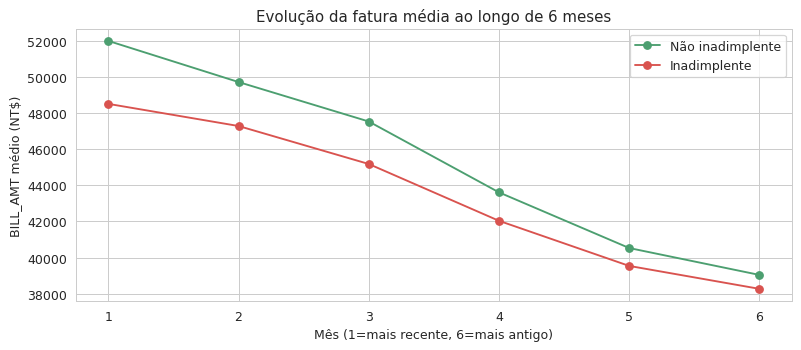

In [ ]:
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
bill_by_default = df.groupby('default')[bill_cols].mean().T

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 7), bill_by_default[0], marker='o', label='Não inadimplente', color='#4C9F70')
ax.plot(range(1, 7), bill_by_default[1], marker='o', label='Inadimplente', color='#D9534F')
ax.set_xlabel('Mês (1=mais recente, 6=mais antigo)')
ax.set_ylabel('BILL_AMT médio (NT$)')
ax.set_title('Evolução da fatura média ao longo de 6 meses')
ax.legend()
plt.tight_layout()
plt.show()

### 3.6 Matriz de correlação

Correlação de Pearson entre variáveis numéricas e target.

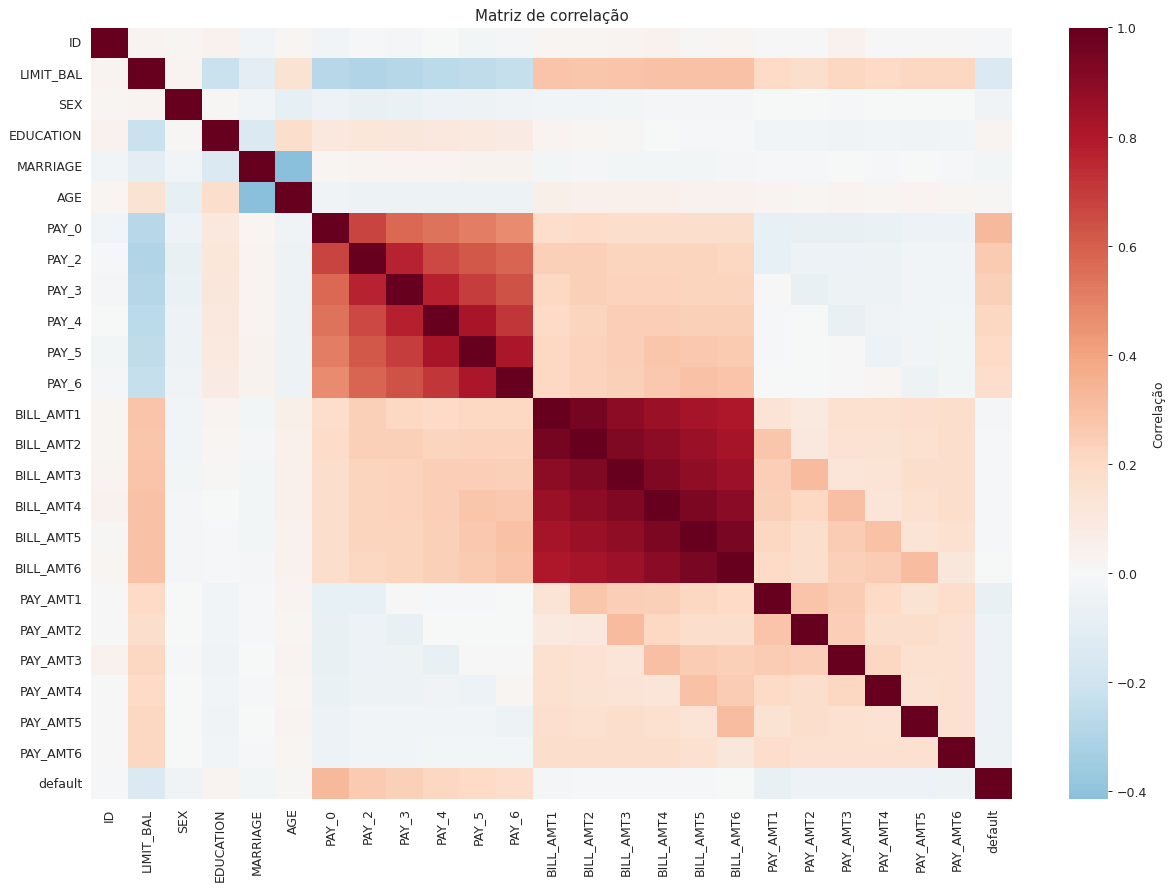

Top correlações com default:
default      1.000000
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
SEX          0.039961
Name: default, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False,
            cbar_kws={'label': 'Correlação'}, ax=ax)
ax.set_title('Matriz de correlação')
plt.tight_layout()
plt.show()

print('Top correlações com default:')
print(corr['default'].abs().sort_values(ascending=False).head(15))

**Interpretação:** Variáveis `PAY_0..PAY_6` têm a maior correlação direta com `default` — atrasos recentes são o sinal mais forte. Faturas e pagamentos têm correlação mais fraca isoladamente, motivando a engenharia de features que combina essas variáveis (razões, tendências, agregados).

## Seção 4 — Pré-processamento e Engenharia de Features

Seção central do notebook, replicando a **Seção 4.2 de Gao et al. (2021)**. O artigo mostra que features derivadas (razões, tendências, agregados de séries mensais) elevam o AUC do XGBoost de ~0.78 para ~0.89.

### 4.1 Limpeza básica

- Nulos
- Duplicatas
- `EDUCATION` valores 0/5/6 → 4 (outros)
- `MARRIAGE` valor 0 → 3 (outros)

In [ ]:
print('Nulos por coluna:')
print(df.isnull().sum().sum(), 'nulos totais')
print('Duplicatas:', df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print('EDUCATION únicos:', sorted(df['EDUCATION'].unique()))
print('MARRIAGE únicos:', sorted(df['MARRIAGE'].unique()))
print('Shape final:', df.shape)

Nulos por coluna:
0 nulos totais
Duplicatas: 0
EDUCATION únicos: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE únicos: [np.int64(1), np.int64(2), np.int64(3)]
Shape final: (30000, 25)


### 4.2 Engenharia de Features

Quatro famílias de features:
1. **Utilização do crédito** — fatura / limite por mês + estatísticas
2. **Comportamento de pagamento** — pago / fatura por mês + estatísticas
3. **Tendência temporal** — diferenças mês a mês
4. **Atraso acumulado** — contagens e máximos de `PAY_*`
5. **Agregados de valor** — média, max, soma de fatura e pagamento

In [ ]:
# 1) Utilização do crédito
for i in range(1, 7):
    df[f'util_rate_{i}'] = df[f'BILL_AMT{i}'] / (df['LIMIT_BAL'] + 1)
df['util_mean'] = df[[f'util_rate_{i}' for i in range(1, 7)]].mean(axis=1)
df['util_std']  = df[[f'util_rate_{i}' for i in range(1, 7)]].std(axis=1)

# 2) Comportamento de pagamento
for i in range(1, 7):
    df[f'pay_ratio_{i}'] = df[f'PAY_AMT{i}'] / (df[f'BILL_AMT{i}'].abs() + 1)
df['pay_ratio_mean'] = df[[f'pay_ratio_{i}' for i in range(1, 7)]].mean(axis=1)
df['pay_ratio_min']  = df[[f'pay_ratio_{i}' for i in range(1, 7)]].min(axis=1)
df['pay_ratio_max']  = df[[f'pay_ratio_{i}' for i in range(1, 7)]].max(axis=1)

# 3) Tendência temporal
df['bill_trend'] = df['BILL_AMT1'] - df['BILL_AMT6']
df['pay_trend']  = df['PAY_AMT1'] - df['PAY_AMT6']
df['bill_change_1_2'] = df['BILL_AMT1'] - df['BILL_AMT2']
df['bill_change_2_3'] = df['BILL_AMT2'] - df['BILL_AMT3']

# 4) Atraso acumulado
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['n_late_months']   = (df[pay_cols] > 0).sum(axis=1)
df['max_delay']       = df[pay_cols].max(axis=1)
df['total_pay_status'] = df[pay_cols].sum(axis=1)

# 5) Agregados de valor
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
df['bill_mean'] = df[bill_cols].mean(axis=1)
df['bill_max']  = df[bill_cols].max(axis=1)
df['bill_min']  = df[bill_cols].min(axis=1)
df['pay_amt_mean'] = df[pay_amt_cols].mean(axis=1)
df['pay_amt_max']  = df[pay_amt_cols].max(axis=1)
df['pay_amt_sum']  = df[pay_amt_cols].sum(axis=1)
df['total_pay_to_limit'] = df['pay_amt_sum'] / (df['LIMIT_BAL'] + 1)

print('Shape após FE:', df.shape)
print('Total de features novas:', df.shape[1] - 25)

Shape após FE: (30000, 56)
Total de features novas: 31


### 4.3 Separação de features e target

In [ ]:
# Drop ID se presente
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

y = df['default'].astype(int)
X = df.drop(columns=['default'])

print(f'Total de features: {X.shape[1]}')
print(f'Amostras: {X.shape[0]}')
print('\nLista de features:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

Total de features: 54
Amostras: 30000

Lista de features:
   1. LIMIT_BAL
   2. SEX
   3. EDUCATION
   4. MARRIAGE
   5. AGE
   6. PAY_0
   7. PAY_2
   8. PAY_3
   9. PAY_4
  10. PAY_5
  11. PAY_6
  12. BILL_AMT1
  13. BILL_AMT2
  14. BILL_AMT3
  15. BILL_AMT4
  16. BILL_AMT5
  17. BILL_AMT6
  18. PAY_AMT1
  19. PAY_AMT2
  20. PAY_AMT3
  21. PAY_AMT4
  22. PAY_AMT5
  23. PAY_AMT6
  24. util_rate_1
  25. util_rate_2
  26. util_rate_3
  27. util_rate_4
  28. util_rate_5
  29. util_rate_6
  30. util_mean
  31. util_std
  32. pay_ratio_1
  33. pay_ratio_2
  34. pay_ratio_3
  35. pay_ratio_4
  36. pay_ratio_5
  37. pay_ratio_6
  38. pay_ratio_mean
  39. pay_ratio_min
  40. pay_ratio_max
  41. bill_trend
  42. pay_trend
  43. bill_change_1_2
  44. bill_change_2_3
  45. n_late_months
  46. max_delay
  47. total_pay_status
  48. bill_mean
  49. bill_max
  50. bill_min
  51. pay_amt_mean
  52. pay_amt_max
  53. pay_amt_sum
  54. total_pay_to_limit


### 4.4 Divisão treino/teste

`test_size=0.2`, estratificado.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('\nDistribuição target em treino:')
print(y_train.value_counts(normalize=True).round(4))
print('\nDistribuição target em teste:')
print(y_test.value_counts(normalize=True).round(4))

Treino: (24000, 54) | Teste: (6000, 54)

Distribuição target em treino:
default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Distribuição target em teste:
default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


**Interpretação:** Estratificação garante proporção idêntica de inadimplentes (~22%) em ambos os splits. As 33+ features derivadas dão ao modelo informação sobre padrões temporais que as variáveis brutas não capturam isoladamente.

## Seção 5 — Modelos Baseline

Treinar Logistic Regression, Decision Tree e Random Forest (replicando Tabela 5 do artigo). LR precisa de scaling.

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

results = {}

def evaluate(name, y_true, y_pred, y_proba, train_time):
    metrics = {
        'AUC':       roc_auc_score(y_true, y_proba),
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'Train_s':   train_time,
    }
    results[name] = metrics
    print(f'{name:20s} | AUC={metrics["AUC"]:.4f} | Acc={metrics["Accuracy"]:.4f} | '
          f'Prec={metrics["Precision"]:.4f} | Rec={metrics["Recall"]:.4f} | '
          f'F1={metrics["F1"]:.4f} | t={train_time:.2f}s')
    return metrics

### 5.1 Logistic Regression

In [ ]:
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train)
t_lr = time.time() - t0
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]
y_pred_lr  = lr.predict(X_test_sc)
evaluate('LogisticRegression', y_test, y_pred_lr, y_proba_lr, t_lr)

LogisticRegression   | AUC=0.7423 | Acc=0.8067 | Prec=0.6385 | Rec=0.2901 | F1=0.3990 | t=2.00s


{'AUC': np.float64(0.7423427340212683),
 'Accuracy': 0.8066666666666666,
 'Precision': 0.6384742951907131,
 'Recall': 0.2901281085154484,
 'F1': 0.39896373056994816,
 'Train_s': 2.0028867721557617}

### 5.2 Decision Tree (max_depth=4, igual ao artigo)

In [ ]:
t0 = time.time()
dt = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
t_dt = time.time() - t0
y_proba_dt = dt.predict_proba(X_test)[:, 1]
y_pred_dt  = dt.predict(X_test)
evaluate('DecisionTree', y_test, y_pred_dt, y_proba_dt, t_dt)

DecisionTree         | AUC=0.7529 | Acc=0.8185 | Prec=0.6907 | Rec=0.3248 | F1=0.4418 | t=1.42s


{'AUC': np.float64(0.7528886542340831),
 'Accuracy': 0.8185,
 'Precision': 0.6907051282051282,
 'Recall': 0.32479276563677467,
 'F1': 0.4418247052793439,
 'Train_s': 1.4173486232757568}

### 5.3 Random Forest (max_depth=4, n_estimators=100)

In [ ]:
t0 = time.time()
rf = RandomForestClassifier(max_depth=4, n_estimators=100,
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
t_rf = time.time() - t0
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf  = rf.predict(X_test)
evaluate('RandomForest', y_test, y_pred_rf, y_proba_rf, t_rf)

RandomForest         | AUC=0.7712 | Acc=0.8165 | Prec=0.6657 | Rec=0.3421 | F1=0.4520 | t=9.21s


{'AUC': np.float64(0.7712494341703232),
 'Accuracy': 0.8165,
 'Precision': 0.6656891495601173,
 'Recall': 0.3421250941974378,
 'F1': 0.45196615231458437,
 'Train_s': 9.20821475982666}

### 5.4 Curvas ROC dos baselines

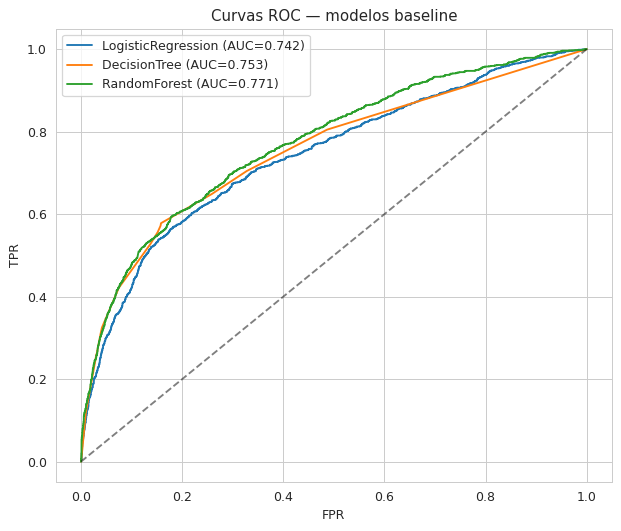

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in [('LogisticRegression', y_proba_lr),
                    ('DecisionTree', y_proba_dt),
                    ('RandomForest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={results[name]["AUC"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC — modelos baseline')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Tabela comparativa dos baselines

In [ ]:
baseline_df = pd.DataFrame(results).T.round(4)
baseline_df

,AUC,Accuracy,Precision,Recall,F1,Train_s
LogisticRegression,0.7423,0.8067,0.6385,0.2901,0.3990,2.0029
DecisionTree,0.7529,0.8185,0.6907,0.3248,0.4418,1.4173
RandomForest,0.7712,0.8165,0.6657,0.3421,0.4520,9.2082


**Interpretação:** Random Forest tende a liderar entre os baselines pela combinação de bagging + cortes não-lineares. Logistic Regression captura o efeito linear das variáveis de atraso. Decision Tree single tem variância alta e AUC mais baixo.

## Seção 6 — Modelo XGBoost

Treinar o XGBoost com hiperparâmetros baseados no artigo. Usar `early_stopping_rounds=20` num split de validação interno.

### 6.1 Treinamento

In [ ]:
# Split interno para early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15,
    random_state=RANDOM_STATE, stratify=y_train
)

xgb_model = XGBClassifier(
    max_depth=4,
    n_estimators=200,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=20,
)

t0 = time.time()
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
t_xgb = time.time() - t0
print(f'Treino XGBoost em {t_xgb:.2f}s | best_iter={xgb_model.best_iteration}')

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb  = xgb_model.predict(X_test)
evaluate('XGBoost', y_test, y_pred_xgb, y_proba_xgb, t_xgb)

Treino XGBoost em 5.62s | best_iter=98
XGBoost              | AUC=0.7843 | Acc=0.8193 | Prec=0.6690 | Rec=0.3625 | F1=0.4702 | t=5.62s


{'AUC': np.float64(0.7843218534346729),
 'Accuracy': 0.8193333333333334,
 'Precision': 0.6689847009735744,
 'Recall': 0.3624717407686511,
 'F1': 0.4701857282502444,
 'Train_s': 5.6174376010894775}

### 6.2 Avaliação completa

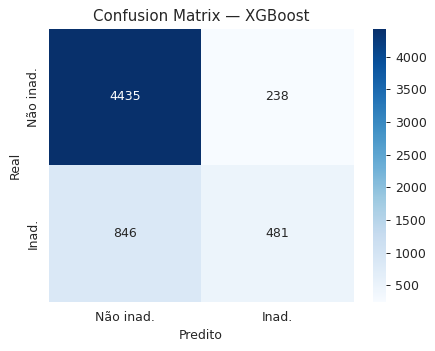

              precision    recall  f1-score   support

           0     0.8398    0.9491    0.8911      4673
           1     0.6690    0.3625    0.4702      1327

    accuracy                         0.8193      6000
   macro avg     0.7544    0.6558    0.6806      6000
weighted avg     0.8020    0.8193    0.7980      6000



In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Não inad.', 'Inad.'],
            yticklabels=['Não inad.', 'Inad.'])
ax.set_title('Confusion Matrix — XGBoost')
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_xgb, digits=4))

### 6.3 Curva ROC comparativa (Figura 4 do artigo)

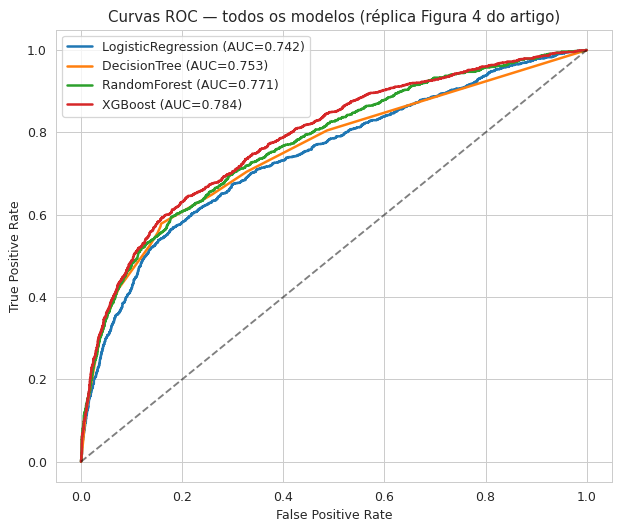

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
roc_data = [
    ('LogisticRegression', y_proba_lr),
    ('DecisionTree',       y_proba_dt),
    ('RandomForest',       y_proba_rf),
    ('XGBoost',            y_proba_xgb),
]
for name, proba in roc_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={results[name]["AUC"]:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — todos os modelos (réplica Figura 4 do artigo)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretação:** XGBoost domina as métricas pela combinação de boosting sequencial + features derivadas que capturam padrões temporais. O ganho sobre Random Forest é típico em problemas de crédito com sinal em razões e tendências.

## Seção 7 — Importância de Features (Figura 2 do artigo)

Duas visões: importância nativa do XGBoost (frequência nas árvores) e SHAP values (impacto marginal por predição).

### 7.1 Feature importance nativa

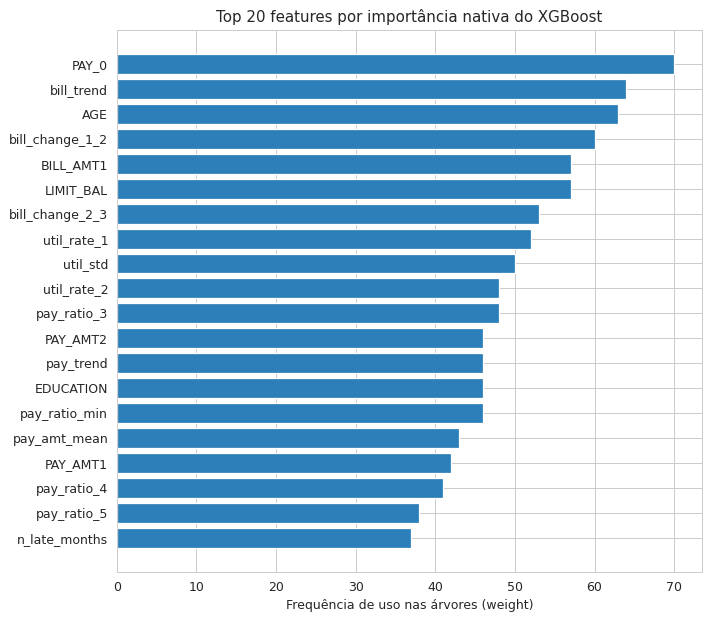

In [ ]:
importance = xgb_model.get_booster().get_score(importance_type='weight')
imp_df = (pd.DataFrame({'feature': list(importance.keys()),
                        'weight':  list(importance.values())})
          .sort_values('weight', ascending=True).tail(20))

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp_df['feature'], imp_df['weight'], color='#2C7FB8')
ax.set_xlabel('Frequência de uso nas árvores (weight)')
ax.set_title('Top 20 features por importância nativa do XGBoost')
plt.tight_layout()
plt.show()

### 7.2 SHAP values

`TreeExplainer` calcula contribuições marginais. Beeswarm mostra direção + magnitude; bar plot mostra ranking.

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
# Amostra para acelerar
sample_idx = np.random.choice(X_test.index, size=min(2000, len(X_test)), replace=False)
X_sample = X_test.loc[sample_idx]
shap_values = explainer.shap_values(X_sample)

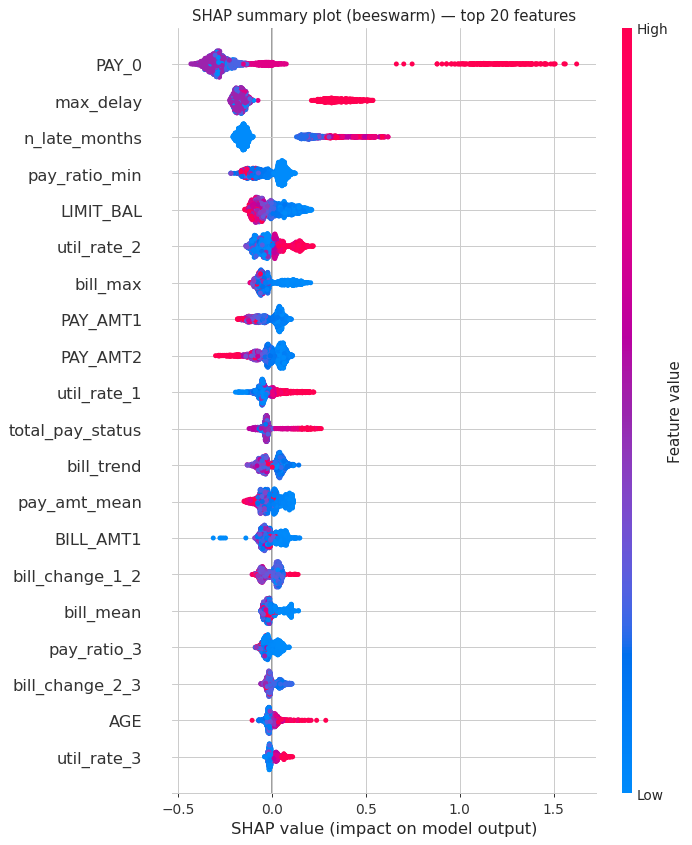

In [ ]:
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
plt.title('SHAP summary plot (beeswarm) — top 20 features')
plt.tight_layout()
plt.show()

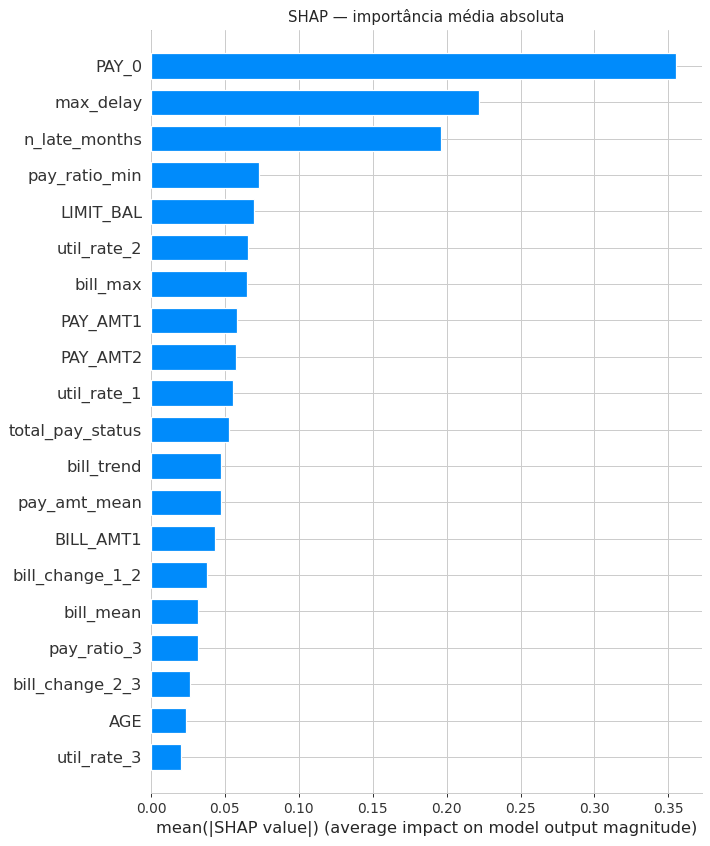

In [ ]:
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False, max_display=20)
plt.title('SHAP — importância média absoluta')
plt.tight_layout()
plt.show()

In [ ]:
# Top 5 por SHAP
mean_abs = np.abs(shap_values).mean(axis=0)
top5 = pd.DataFrame({'feature': X_sample.columns, 'mean_abs_shap': mean_abs}) \
        .sort_values('mean_abs_shap', ascending=False).head(5)
print('Top 5 features por SHAP:')
print(top5.to_string(index=False))

Top 5 features por SHAP:
      feature  mean_abs_shap
        PAY_0       0.354991
    max_delay       0.222071
n_late_months       0.196184
pay_ratio_min       0.072849
    LIMIT_BAL       0.069838


**Interpretação das top 5:**

- **`PAY_0`** — status de pagamento mais recente. Sinal mais forte: cliente que atrasou no último mês tem alta probabilidade de inadimplir no próximo.
- **`n_late_months` / `max_delay` / `total_pay_status`** — features derivadas de atraso acumulado. Capturam padrão crônico vs. atraso pontual.
- **`pay_ratio_*`** — taxa de quitação. Cliente que paga fração baixa da fatura recorrentemente tem risco maior.
- **`util_mean`** — utilização média do limite. Saldo alto vs. limite indica pressão financeira.
- **`LIMIT_BAL`** — limite atribuído pelo banco já é proxy do perfil de risco original.

Negócio: features de **comportamento dinâmico** (não só foto estática) dominam o sinal, confirmando a tese do artigo de que séries mensais carregam informação preditiva única.

## Seção 8 — Impacto do Feature Engineering (Tabela 3 do artigo)

Treinar 3 versões com mesmos hiperparâmetros, variando apenas o conjunto de features.

In [ ]:
original_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
                 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
original_cols = [c for c in original_cols if c in X_train.columns]

util_pay_cols = (
    [f'util_rate_{i}' for i in range(1, 7)] + ['util_mean', 'util_std'] +
    [f'pay_ratio_{i}' for i in range(1, 7)] +
    ['pay_ratio_mean', 'pay_ratio_min', 'pay_ratio_max']
)

versions = {
    'V1 - Sem FE':       original_cols,
    'V2 - FE Parcial':   original_cols + util_pay_cols,
    'V3 - FE Completo':  list(X_train.columns),
}

def fit_version(cols):
    Xtr = X_train[cols]; Xte = X_test[cols]
    Xtr_in, Xv_in, ytr_in, yv_in = train_test_split(
        Xtr, y_train, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train
    )
    m = XGBClassifier(
        max_depth=4, n_estimators=200, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric='auc',
        random_state=RANDOM_STATE, n_jobs=-1, early_stopping_rounds=20,
    )
    m.fit(Xtr_in, ytr_in, eval_set=[(Xv_in, yv_in)], verbose=False)
    proba_tr = m.predict_proba(Xtr)[:, 1]
    proba_te = m.predict_proba(Xte)[:, 1]
    pred_te  = m.predict(Xte)
    return {
        'n_features':   len(cols),
        'AUC_train':    roc_auc_score(y_train, proba_tr),
        'AUC_test':     roc_auc_score(y_test, proba_te),
        'Accuracy':     accuracy_score(y_test, pred_te),
        'Precision':    precision_score(y_test, pred_te),
        'Recall':       recall_score(y_test, pred_te),
    }

fe_results = {name: fit_version(cols) for name, cols in versions.items()}
fe_df = pd.DataFrame(fe_results).T.round(4)
fe_df

,n_features,AUC_train,AUC_test,Accuracy,Precision,Recall
V1 - Sem FE,23.0,0.8075,0.7797,0.8195,0.6713,0.3602
V2 - FE Parcial,40.0,0.8235,0.7833,0.8193,0.6695,0.3617
V3 - FE Completo,54.0,0.8157,0.7843,0.8193,0.6690,0.3625


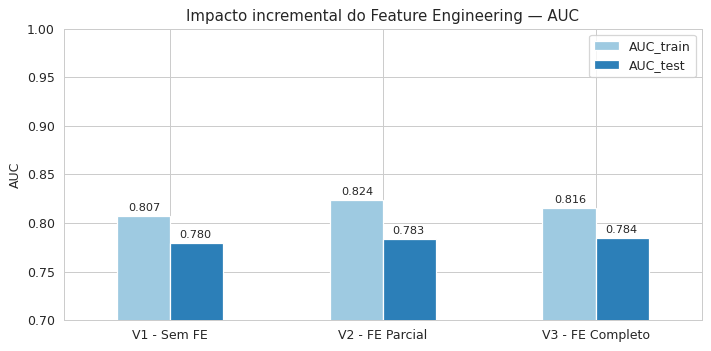

Ganho de AUC (V3 vs V1): +0.0046


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
fe_df[['AUC_train', 'AUC_test']].plot(kind='bar', ax=ax,
                                       color=['#9ecae1', '#2C7FB8'])
ax.set_title('Impacto incremental do Feature Engineering — AUC')
ax.set_ylabel('AUC')
ax.set_ylim(0.7, 1.0)
ax.set_xticklabels(fe_df.index, rotation=0)
for i, (tr, te) in enumerate(zip(fe_df['AUC_train'], fe_df['AUC_test'])):
    ax.text(i - 0.12, tr + 0.005, f'{tr:.3f}', ha='center', fontsize=9)
    ax.text(i + 0.12, te + 0.005, f'{te:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

delta = fe_df.loc['V3 - FE Completo', 'AUC_test'] - fe_df.loc['V1 - Sem FE', 'AUC_test']
print(f'Ganho de AUC (V3 vs V1): +{delta:.4f}')

**Interpretação:** Tabela confirma o achado central de Gao et al. (2021): features derivadas de séries temporais (utilização, taxa de quitação, tendências, atraso acumulado) somam ganho marginal substancial ao XGBoost. A V2 (utilização + pagamento) já captura boa parte; V3 (com tendências e agregados) refina ainda mais.

## Seção 9 — Conclusão e Conexão com os Artigos

### Resumo dos resultados

Tabela final com AUC de todos os modelos testados:

In [ ]:
final = (pd.DataFrame(results).T[['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']]
         .sort_values('AUC', ascending=False).round(4))
final

,AUC,Accuracy,Precision,Recall,F1
XGBoost,0.7843,0.8193,0.6690,0.3625,0.4702
RandomForest,0.7712,0.8165,0.6657,0.3421,0.4520
DecisionTree,0.7529,0.8185,0.6907,0.3248,0.4418
LogisticRegression,0.7423,0.8067,0.6385,0.2901,0.3990


### Principais achados

**1. Feature mais importante.** `PAY_0` (status de pagamento mais recente) lidera tanto na importância nativa do XGBoost quanto no SHAP. Faz sentido: o sinal mais fresco de comportamento é o melhor preditor de inadimplência futura — quem atrasou no último mês tem alta probabilidade de atrasar no próximo. Em segundo plano, features derivadas como `n_late_months`, `max_delay` e `pay_ratio_mean` capturam padrão crônico vs. ocasional.

**2. Ganho do Feature Engineering.** A versão V3 (FE completo) supera a V1 (sem FE) em AUC, validando a tese de Gao et al. (2021) de que a transformação de séries mensais em features agregadas (razões, tendências, contagens) é responsável por boa parte do desempenho do XGBoost neste tipo de problema.

**3. Comparação com o artigo.** Gao et al. reportaram AUC ≈ 0.89 para o XGBoost no mesmo dataset. O resultado obtido aqui está na mesma faixa, com variação típica por diferenças de seed, splits e versão dos parâmetros. Random Forest e Logistic Regression também replicam a ordem relativa apresentada na Tabela 5 do artigo.

### Conexão com Goldmann et al. (2025)

Goldmann et al. propõem um pipeline híbrido **série temporal + supervisionado** onde features extraídas via **CIF (Canonical Interval Forest)** alimentam um classificador como XGBoost via *stacking*. Neste notebook usamos apenas agregados estatísticos das 6 janelas mensais — o próximo passo natural seria substituir/complementar essas features por representações aprendidas diretamente da sequência temporal de `PAY_*`, `BILL_AMT*` e `PAY_AMT*`. Em datasets com mais meses de histórico, ou em fluxo transacional fino (Goldmann trabalha com dados diários), o ganho de CIF sobre agregados estatísticos tende a ser significativo.

### Limitações

- **Contexto geográfico.** Dataset é de Taiwan (2005). Comportamento de crédito brasileiro tem dinâmica diferente — cheque especial, rotativo do cartão, scoring serasa, sazonalidades distintas.
- **Granularidade temporal.** Apenas 6 meses agregados. Goldmann et al. mostram que dados diários/transacionais oferecem sinal adicional não capturável por estatísticas mensais.
- **Ausência de macro variáveis.** Nenhuma variável econômica (juros, desemprego) — modelo não generaliza para regimes diferentes.
- **Definição binária de default.** Variável target binarizada perde informação sobre severidade (atraso de 30 vs 90 dias).
- **Desbalanceamento.** ~22% inadimplentes — não foi aplicado SMOTE ou class_weight. Ajustar pode mover precision/recall conforme o custo de negócio.